# Load libraries

In [97]:
import numpy as np
import itertools, pandas as pd
from models import LinearModel, ChoquetModel
from pymoo_tests import ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2

import matplotlib.pyplot as plt
from utils import evaluate, visualise_weights

# Modelling

In [98]:
# ZDT calling
# linear_model = LinearModel(problem = ZDT2(n_dim = 10), max_iter = 50, random_state = 42)
# choquet_model = ChoquetModel(problem = ZDT2(n_dim = 10), max_iter = 50, random_state = 42, method = 2)

# DTLZ calling
linear_model = LinearModel(problem = DTLZ1(n_dim = 10, n_obj = 2), max_iter = 50, random_state = 42)
choquet_model = ChoquetModel(problem = DTLZ1(n_dim = 10, n_obj = 2), max_iter = 50, random_state = 42, method = 2)

# Let them solve
linear_model.solve()
choquet_model.solve()

# Summary their performance metrics

print(f"LinearModel :  PF {linear_model.PF.shape}  PS {linear_model.PS.shape}")
print(f"ChoquetModel:  PF {choquet_model.PF.shape} PS {choquet_model.PS.shape}")
evaluate([linear_model, choquet_model])

LinearModel :  PF (130, 2)  PS (130, 10)
ChoquetModel:  PF (250, 2) PS (250, 10)


,hypervolume,n_func_eval,n_non_dominated,n_iter,wallclock_time
LinearModel,362718.338111,5016,130,50,0.895048
ChoquetModel,368626.175544,6699,250,50,16.110592


# Model visualisation

In [99]:
# for kind in ["symmetric", "absolute", "norm"]:
#     visualise_weights(choquet_model, kind = kind);

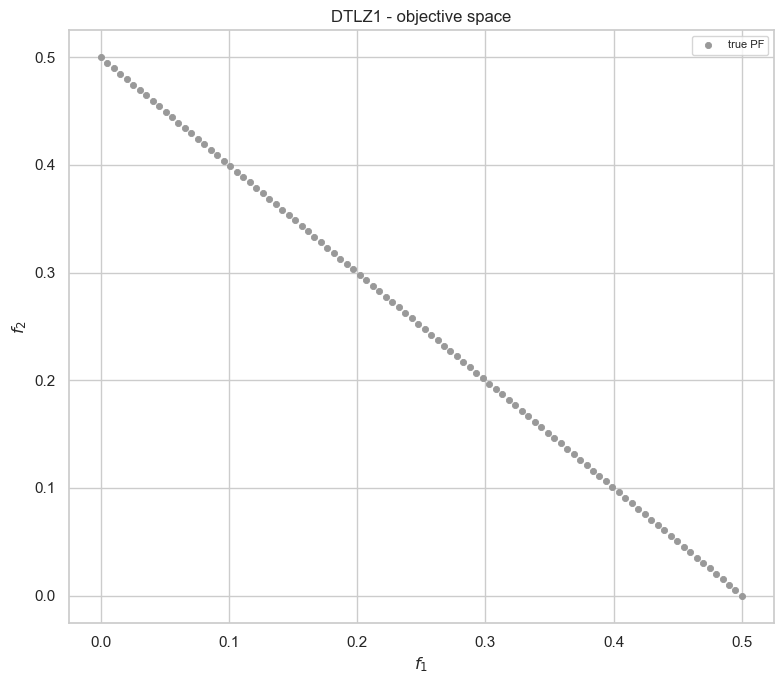

In [100]:
linear_model.visualise("true_pf");

## Linear Model

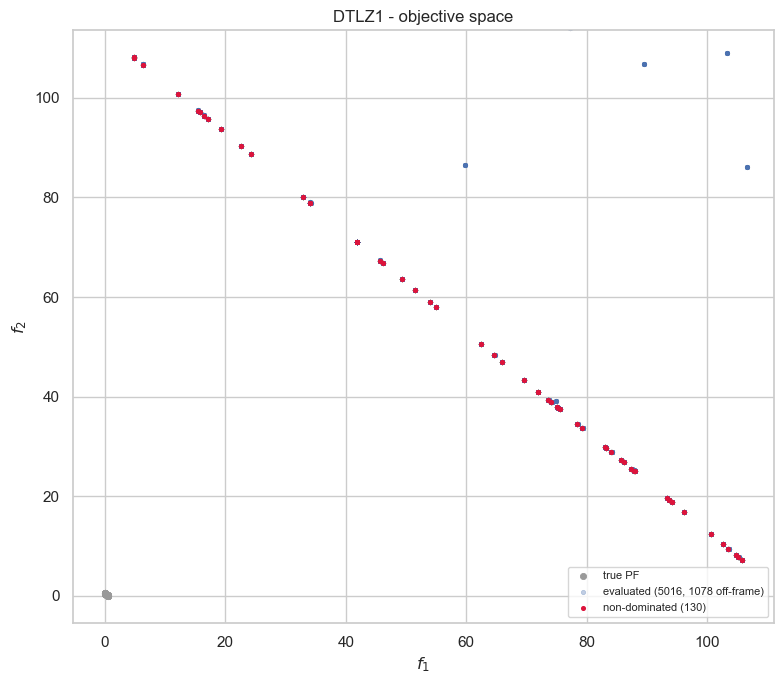

In [101]:
linear_model.visualise("objective");

In [102]:
linear_model.visualise("learning", show = False)

In [103]:
linear_model.visualise("learning", plot_scalarisation = True, show = False)

## Choquet Model

In [104]:
np.all((choquet_model.dec_hist >= 0) & (choquet_model.dec_hist <= 1))

np.True_

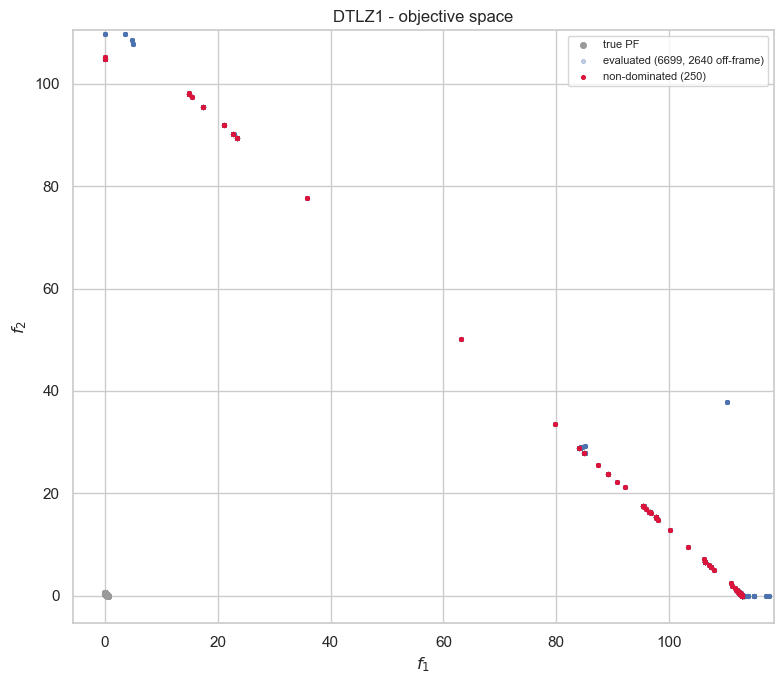

In [105]:
choquet_model.visualise("objective");

In [106]:
choquet_model.visualise("learning", show = False)

In [107]:
choquet_model.visualise("learning", plot_scalarisation = True, show = False)

# Benchmark

Every configuration is solved by both models from the same seed, then scored by `evaluate()` against one shared reference point.

- **ZDT1/2/3** are 2-objective by construction, so they appear once per `n_dim` and ignore `obj_dims`.
- **DTLZ1/2** take `n_obj`, and are skipped when `n_dim <= n_obj` - there would be no tail variables left to carry `g`.
- Hypervolume is comparable **within** a row group only; the reference point differs between configurations, so never compare it across problems or dimensions.

In [12]:
dec_dims   = [10, 20]
obj_dims   = [2, 3, 4, 5]
max_iter   = 50
model_list = [LinearModel, ChoquetModel]
prob_list  = [ZDT1, ZDT2, ZDT3, DTLZ1, DTLZ2]


def build(problem, n_dim, n_obj):
    """This grid cell's problem, or None if the combination does not exist: ZDT is 2-objective by
       construction, and DTLZ needs n_dim > n_obj to leave tail variables to carry g."""
    if problem in (ZDT1, ZDT2, ZDT3):
        return problem(n_dim = n_dim) if n_obj == 2 else None
    return problem(n_dim = n_dim, n_obj = n_obj) if n_dim > n_obj else None


rows = []
for problem, n_dim, n_obj in itertools.product(prob_list, dec_dims, obj_dims):
    prob = build(problem, n_dim, n_obj)
    if prob is None:
        continue

    fitted = [model(problem = prob, max_iter = max_iter, random_state = 42,
                    **(dict(method = 2) if model is ChoquetModel else {}))
              for model in model_list]
    for m in fitted:
        m.solve()

    # evaluate() scores the pair against one shared reference point, and already times each solve
    rows.append(evaluate(fitted).assign(problem = problem.__name__, n_dim = n_dim,
                                        n_obj = prob.n_obj))
    print(problem.__name__, f"n_dim={n_dim}", f"n_obj={prob.n_obj}",
          dict(rows[-1]["wallclock_time"].round(1)))

results = (pd.concat(rows).rename_axis("model").reset_index()
             .set_index(["problem", "n_dim", "n_obj", "model"]).sort_index())
results

ZDT1 n_dim=10 n_obj=2 {'LinearModel': np.float64(1.3), 'ChoquetModel': np.float64(58.4)}
ZDT1 n_dim=20 n_obj=2 {'LinearModel': np.float64(2.6), 'ChoquetModel': np.float64(70.7)}
ZDT2 n_dim=10 n_obj=2 {'LinearModel': np.float64(0.2), 'ChoquetModel': np.float64(5.7)}
ZDT2 n_dim=20 n_obj=2 {'LinearModel': np.float64(0.6), 'ChoquetModel': np.float64(2.8)}
ZDT3 n_dim=10 n_obj=2 {'LinearModel': np.float64(1.6), 'ChoquetModel': np.float64(35.3)}
ZDT3 n_dim=20 n_obj=2 {'LinearModel': np.float64(5.6), 'ChoquetModel': np.float64(53.7)}
DTLZ1 n_dim=10 n_obj=2 {'LinearModel': np.float64(1.0), 'ChoquetModel': np.float64(15.4)}
DTLZ1 n_dim=10 n_obj=3 {'LinearModel': np.float64(0.9), 'ChoquetModel': np.float64(31.4)}
DTLZ1 n_dim=10 n_obj=4 {'LinearModel': np.float64(1.2), 'ChoquetModel': np.float64(144.9)}
DTLZ1 n_dim=10 n_obj=5 {'LinearModel': np.float64(1.1), 'ChoquetModel': np.float64(744.0)}
DTLZ1 n_dim=20 n_obj=2 {'LinearModel': np.float64(2.5), 'ChoquetModel': np.float64(8.4)}
DTLZ1 n_dim=20 n_

hypervolume  n_func_eval  n_non_dominated  \
problem n_dim n_obj model                                                      
DTLZ1   10    2     ChoquetModel  3.686262e+05         6699              250   
                    LinearModel   3.627183e+05         5016              130   
              3     ChoquetModel  9.574181e+07         6325              356   
                    LinearModel   9.421264e+07         4840              180   
              4     ChoquetModel  1.821544e+10         5918              920   
                    LinearModel   1.790841e+10         5115              288   
              5     ChoquetModel  5.529084e+11        11814             2515   
                    LinearModel   5.434052e+11         5049              346   
        20    2     ChoquetModel  1.997934e+06        15099               60   
                    LinearModel   1.993916e+06         9597              108   
              3     ChoquetModel  9.977496e+08        15624              657   
                    LinearModel   9.912687e+08         9534              156   
              4     ChoquetModel  3.222281e+11        23142             1789   
                    LinearModel   3.198254e+11         9555              224   
              5     ChoquetModel  1.050122e+14        31920             3697   
                    LinearModel   1.048899e+14         9849              837   
DTLZ2   10    2     ChoquetModel  9.758657e+00         7546              451   
                    LinearModel   9.718234e+00         2398               16   
              3     ChoquetModel  1.887386e+01        12892             1662   
                    LinearModel   1.874152e+01         2563               73   
              4     ChoquetModel  4.388995e+01         4565              214   
                    LinearModel   4.377938e+01         2673              233   
              5     ChoquetModel  9.256607e+01         5489              917   
                    LinearModel   9.252087e+01         2926              344   
        20    2     ChoquetModel  3.225528e+01        15456              472   
                    LinearModel   3.224106e+01         4683               32   
              3     ChoquetModel  1.124647e+02        19320             1261   
                    LinearModel   1.123295e+02         4452               73   
              4     ChoquetModel  5.055554e+02         9282              117   
                    LinearModel   5.055744e+02         4578              179   
              5     ChoquetModel  1.379107e+03        14595              305   
                    LinearModel   1.379155e+03         4347              228   
ZDT1    10    2     ChoquetModel  9.240411e+00        15103              906   
                    LinearModel   9.653069e+00         5489              778   
        20    2     ChoquetModel  9.356519e+00        30198              978   
                    LinearModel   9.659916e+00        10752              684   
ZDT2    10    2     ChoquetModel  9.148885e+00         1738              106   
                    LinearModel   9.028372e+00         1771               30   
        20    2     ChoquetModel  9.106175e+00         3948               12   
                    LinearModel   8.900000e+00         4284                4   
ZDT3    10    2     ChoquetModel  1.003189e+01        13288              695   
                    LinearModel   9.859463e+00         8184              390   
        20    2     ChoquetModel  9.539831e+00        38724              637   
                    LinearModel   9.861534e+00        18879              483   

                                  n_iter  wallclock_time  
problem n_dim n_obj model                                 
DTLZ1   10    2     ChoquetModel      50       15.448413  
                    LinearModel       50        1.028273  
              3     ChoquetModel      50       31.365692  
                    LinearModel       50        0.934335  


In [13]:
# hypervolume only compares within a configuration, so pick a winner per row
hv = results["hypervolume"].unstack("model")
hv.assign(winner = hv.idxmax(1), gap_pct = 100 * (hv.max(1) - hv.min(1)) / hv.max(1)).round(4)

model                ChoquetModel   LinearModel        winner  gap_pct
problem n_dim n_obj                                                   
DTLZ1   10    2      3.686262e+05  3.627183e+05  ChoquetModel   1.6027
              3      9.574181e+07  9.421264e+07  ChoquetModel   1.5972
              4      1.821544e+10  1.790841e+10  ChoquetModel   1.6855
              5      5.529084e+11  5.434052e+11  ChoquetModel   1.7188
        20    2      1.997934e+06  1.993916e+06  ChoquetModel   0.2011
              3      9.977496e+08  9.912687e+08  ChoquetModel   0.6496
              4      3.222281e+11  3.198254e+11  ChoquetModel   0.7457
              5      1.050122e+14  1.048899e+14  ChoquetModel   0.1165
DTLZ2   10    2      9.758700e+00  9.718200e+00  ChoquetModel   0.4142
              3      1.887390e+01  1.874150e+01  ChoquetModel   0.7012
              4      4.389000e+01  4.377940e+01  ChoquetModel   0.2519
              5      9.256610e+01  9.252090e+01  ChoquetModel   0.0488
        20    2      3.225530e+01  3.224110e+01  ChoquetModel   0.0441
              3      1.124647e+02  1.123295e+02  ChoquetModel   0.1203
              4      5.055554e+02  5.055744e+02   LinearModel   0.0038
              5      1.379107e+03  1.379156e+03   LinearModel   0.0035
ZDT1    10    2      9.240400e+00  9.653100e+00   LinearModel   4.2749
        20    2      9.356500e+00  9.659900e+00   LinearModel   3.1408
ZDT2    10    2      9.148900e+00  9.028400e+00  ChoquetModel   1.3172
        20    2      9.106200e+00  8.900000e+00  ChoquetModel   2.2641
ZDT3    10    2      1.003190e+01  9.859500e+00  ChoquetModel   1.7188
        20    2      9.539800e+00  9.861500e+00   LinearModel   3.2622